# Simulate data

In order to make initial tests better interpretable, we simulate some very basic spectra.

The atmosphere solely consists of constant NO2 values (which are therefore modulated by the AMF).

The instrument is only applying
* convolution to a Gaussian with FWHM=0.5 nm and a 0.1 nm step/pixel.
* non-linearity.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### SZA values
Linearlily spaced in the AMF between AMF 1 to 9, using simplified AMF function

AMF $= \dfrac{1}{\cos(\alpha)}$

In [2]:
sza = np.around(np.arccos(1./np.linspace(1,9,100))*180./np.pi, 2)
sza[0] = 1.
sza = sza[::4]  # for now only 25 out of 100 szas
print(sza)

[ 1.   40.91 52.6  59.49 64.14 67.53 70.11 72.15 73.81 75.18 76.33 77.32
 78.17 78.92 79.57 80.15 80.68 81.14 81.57 81.95 82.3  82.62 82.92 83.19
 83.44]


## Simulation setup

In [3]:
from SIMPLE import SIMPLE as sim

In [4]:
sim.__version__

'0.5.0'

In [5]:
scenario = "onesun-v1"

scenarioUpdates = {
    "solar zenith angles": "1."
}
s_tmp = sim.SIMPLE(scenario, scenarioUpdate=scenarioUpdates, printOutput=True)  # level 01 is not saved - too large!

## L01 data

In [6]:
l01 = s_tmp.GetLevel(lev='01')

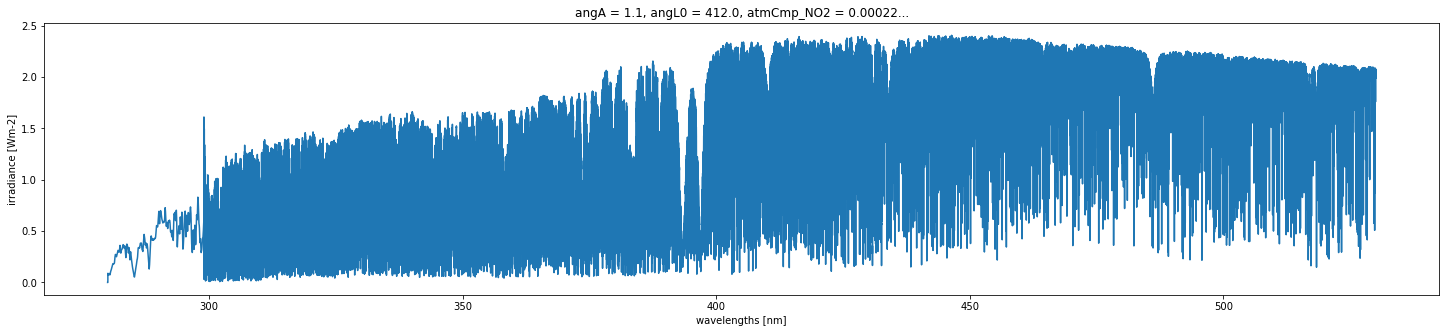

In [7]:
l01.irr.plot(size=5, aspect=5)
plt.show()

## L0 data

In [8]:
scenario = "onesun-v1"

scenarioUpdates = {
    "solar zenith angles": ','.join(sza.astype(str).tolist()),  # sza values from above
}
s = sim.SIMPLE(scenario, scenarioUpdate=scenarioUpdates, printOutput=True, byPassSaving=['01'])  # level 01 is not saved - too large!

In [9]:
l0 = s.GetLevel(lev='0')

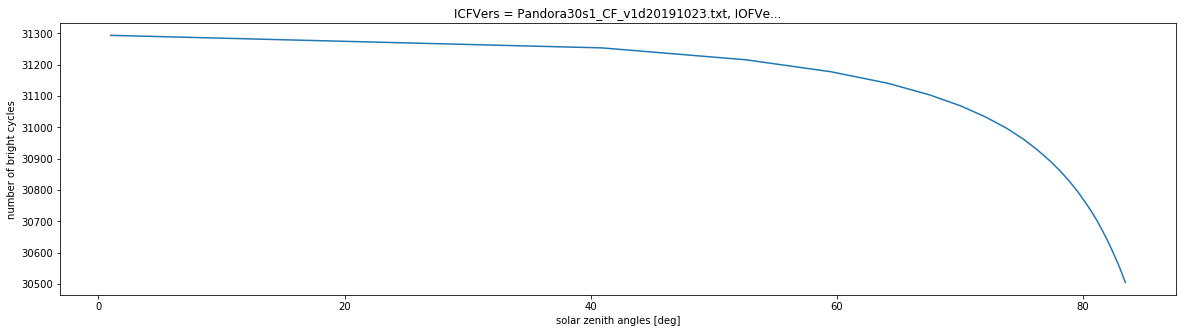

In [10]:
l0.nbc.plot(size=5, aspect=4)
plt.show()

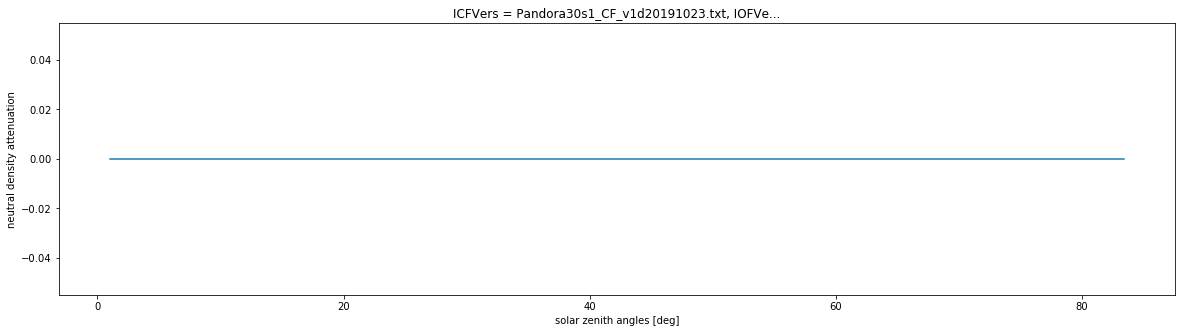

In [11]:
l0.nd.plot(size=5, aspect=4)
plt.show()

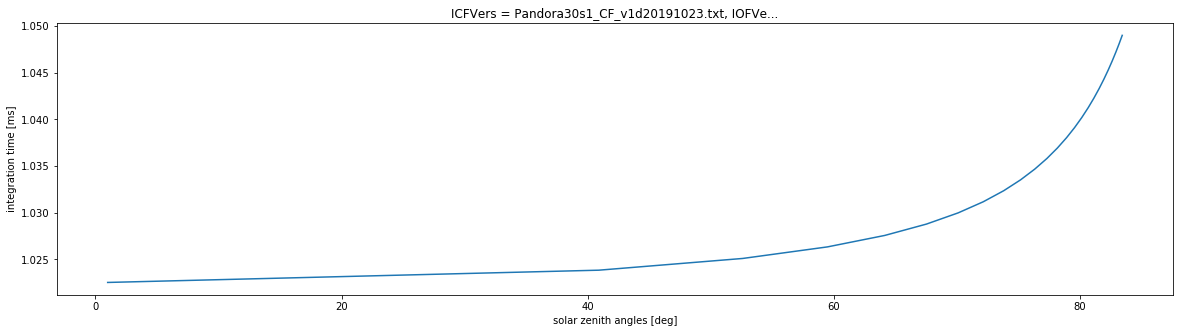

In [12]:
l0.it.plot(size=5, aspect=4)
plt.show()

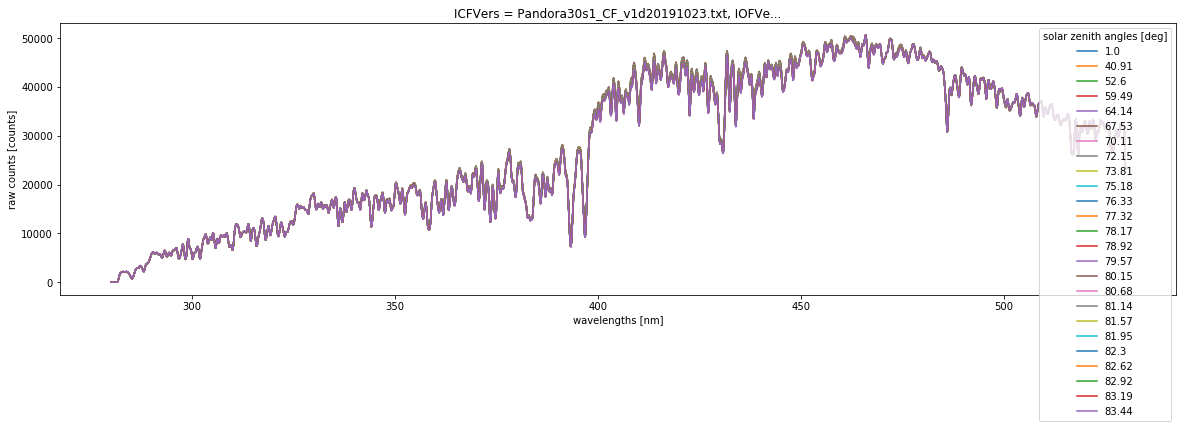

In [13]:
l0.c.plot(hue='sza', size=5, aspect=4)
plt.show()

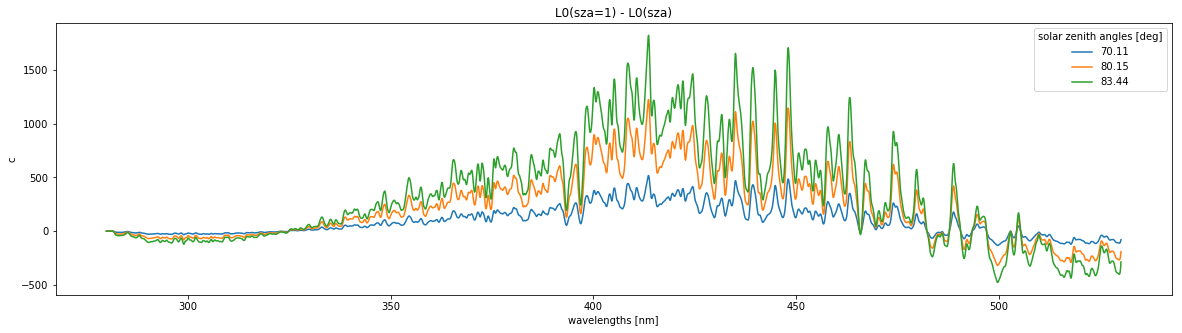

In [14]:
(l0.c.sel(sza=1.0) - l0.c.sel(sza=[70.11,80.15,83.44])).plot(hue='sza', size=5, aspect=4)
plt.title('L0(sza=1) - L0(sza)')
plt.show()

## L1 data (only needed for aux data line temps, nds and integration time)

In [15]:
l1 = s.GetLevel(lev='1')

In [16]:
l1

<xarray.Dataset>
Dimensions:                 (lam: 2501, sza: 25)
Coordinates:
    ICFVers                 <U30 u'Pandora30s1_CF_v1d20191023.txt'
    ICFVersCor              <U30 u'Pandora30s1_CF_v1d20191023.txt'
    IOFVers                 <U28 u'Pandora30_OF_v1d20190910.txt'
    adBitNum                int32 16
    addNoiseBeta            float64 inf
    addNoiseRun             int32 0
    addNoiseScale           float64 inf
    angA                    float64 1.1
    angL0                   float64 412.0
    atmCmp_NO2              float64 0.0002231
    atmPresChnge            float64 0.0
    atmProf                 |S6 'afglus'
    convToCounts            bool True
    corFF                   bool False
    corLat                  bool False
    corNonLin               bool False
    corRadTempCor           bool False
    corSens                 int32 0
    coreCut                 float64 0.01
    corrToCountRates        bool True
    darkRatio               float64 0.2
    datCorF

## Convert to pickle in requested format

In [32]:
import xarray as xr
l0_1 = xr.merge([l0, l1])

In [37]:
l0_1

<xarray.Dataset>
Dimensions:                 (lam: 2501, sza: 25)
Coordinates:
    ICFVers                 <U30 u'Pandora30s1_CF_v1d20191023.txt'
    IOFVers                 <U28 u'Pandora30_OF_v1d20190910.txt'
    adBitNum                int32 16
    addNoiseBeta            float64 inf
    addNoiseRun             int32 0
    addNoiseScale           float64 inf
    angA                    float64 1.1
    angL0                   float64 412.0
    atmCmp_NO2              float64 0.0002231
    atmPresChnge            float64 0.0
    atmProf                 |S6 'afglus'
    convToCounts            bool True
    corFF                   bool False
    corLat                  bool False
    corNonLin               bool False
    corRadTempCor           bool False
    coreCut                 float64 0.01
    corrToCountRates        bool True
    darkRatio               float64 0.2
    detector                |S21 'Hama_S11071 (2048x64)'
    doConv                  bool True
    doDiscFwdM     

In [92]:
def convert_to_dataframe(ds):
    # Convert the relevant 1D variables into a DataFrame.
    # This assumes they are indexed by the coordinate 'sza'.
    df_vars = ds[['time', 'tint', 'fw1p', 'fw2p']].to_dataframe().reset_index()

    rows = []
    for i, row in df_vars.iterrows():
        sza_val = row['sza']
        time_val = row['time']
        tint_val = row['tint']
        fw1p_val = int(row['fw1p'])
        fw2p_val = int(row['fw2p'])
        effRadTemp = row['effRadTemp']

        # Extract the corresponding 1D array (over 'lam') from 'c'
        data_list = ds['c'].sel(sza=sza_val).values.tolist()

        new_row = {
            "time": time_val,
            "routine_code": "SQ",
            "integration_time": tint_val,
            "routine_count": i+1,
            "repetition_count": "1",
            "filterwheel_pos1": fw1p_val,
            "filterwheel_pos2": fw2p_val,
            "aux_spec_temp": effRadTemp,
            "head_sens_temp": effRadTemp,
            "elec_temp1": effRadTemp,
            "data": data_list,
            "date": pd.to_datetime(time_val).strftime("%Y%m%d"),
        }
        rows.append(new_row)

    final_df = pd.DataFrame(rows)

    # Ensure the DataFrame columns are in the specified order
    columns_order = [
        "time", "routine_code", "integration_time", "routine_count", "repetition_count",
        "filterwheel_pos1", "filterwheel_pos2", "aux_spec_temp", "head_sens_temp",
        "elec_temp1", "data", "date"
    ]
    final_df = final_df[columns_order]

    # Set "time" as the index of the DataFrame.
    final_df = final_df.set_index("time")

    return final_df


In [93]:
# l0_1.time.data
df = convert_to_dataframe(l0_1)

In [97]:
df.to_pickle("PandoraS_Timbuktu_{}_{}.pkl".format(df.date[0], df.date[-1]))

## Extraterrestrial reference
Gaussian slit is cut at 0.01 level (normalized slit function)

In [17]:
f0 = s.GetLevel(lev='F')

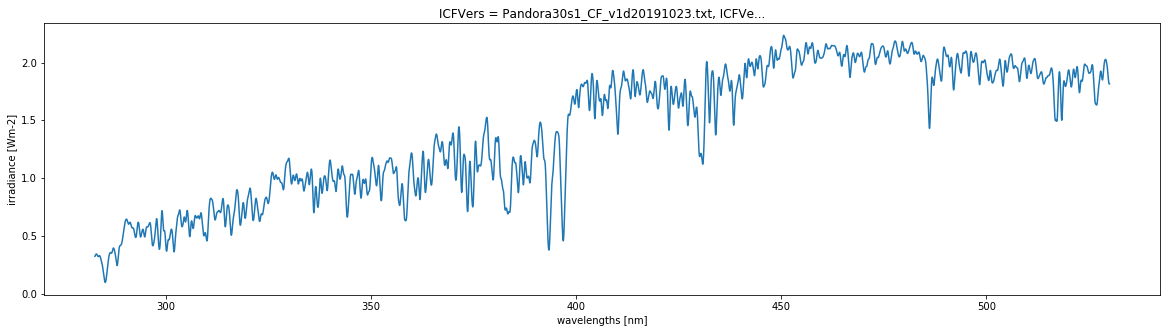

In [18]:
f0.irr.plot(size=5, aspect=4)
plt.show()

## Convert to pickle in requested format


In [119]:
def convert_to_dataframe_ref(ds, vars=None, index=None):
    # Extract the values from the 'lam' coordinate and the 'irr' variable.
    if vars is None:
        vars = {'lam': 'wl', 'irr': 'data'}

    data = {}
    for var in vars.keys():
        name = vars[var]
        data.update({name: ds[var]})

    # Create a DataFrame with the desired column names.
    df = pd.DataFrame(data)

    if index is not None:
        df = df.set_index(index)

    return df

In [122]:
df_f0 = convert_to_dataframe_ref(f0, vars={'lam': 'wl', 'irr': 'data'}, index='wl')

In [124]:
df_f0.to_pickle("solar_conv05.pkl")

## Cross-sections (as relative optical depths)
Gaussian slit is cut at 0.01 level (normalized slit function)

In [19]:
r = s.GetLevel(lev='R')

In [20]:
er = s.GetLevel(lev='ER')

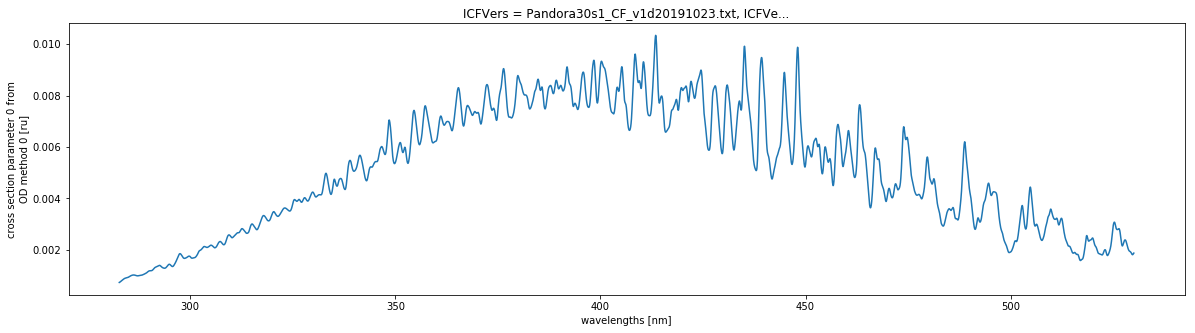

In [21]:
er.sel(dTempODFit=0)['0'].plot(size=5, aspect=4)
plt.show()

In [131]:
er['0']

<xarray.DataArray '0' (dTempODFit: 5, lam: 5001)>
array([[     nan,      nan,      nan, ..., 0.001835, 0.001852, 0.001868],
       [     nan,      nan,      nan, ..., 0.001839, 0.001854, 0.001868],
       [     nan,      nan,      nan, ..., 0.001842, 0.001855, 0.001868],
       [     nan,      nan,      nan, ..., 0.001846, 0.001857, 0.001868],
       [     nan,      nan,      nan, ..., 0.001849, 0.001859, 0.001867]])
Coordinates:
    ICFVers          <U30 u'Pandora30s1_CF_v1d20191023.txt'
    ICFVersCor       <U30 u'Pandora30s1_CF_v1d20191023.txt'
    IOFVers          <U28 u'Pandora30_OF_v1d20190910.txt'
    atmProf          |S6 'afglus'
    coreCut          float64 0.01
  * dTempODFit       (dTempODFit) float64 -40.0 -20.0 0.0 20.0 40.0
    doConv           bool True
    doDiscRef        bool True
    doSensWeightRef  bool True
    gasesRef         |S3 'NO2'
  * lam              (lam) float64 280.0 280.1 280.1 280.1 ... 529.9 530.0 530.0
    nPixTr           |S3 '-1.'
    nPixTrResFac

In [132]:
df_er = convert_to_dataframe_ref(er.sel(dTempODFit=0), vars={'lam': 'wl', '0': 'NO2'}, index='wl')

In [134]:
df_er.to_pickle("gas_ods_conv05.pkl")